In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
def StoN_ADU(N, n_pixels, n_b, gain, NS, RN, ND):
    RN_adu = RN / gain
    ND_adu = ND / gain

    return N / np.sqrt(
        (N / gain) +
        n_pixels * (1 + n_pixels / n_b) * ((NS / gain) + ND_adu + RN_adu**2)
    )

def process_apt_file(name, band, nmgy, gain, nd, read_noise=5.0):
    data = pd.read_csv(name)

    N = data['SourceIntensity'] / nmgy
    NS = data['SkyMedian'] / nmgy
    n_pixels = data['ApertureNumPixels']
    n_b = data['SkyNumPixels']
    aperture_pixels = data['ApertureMinorRadius']

    sn = StoN_ADU(N, n_pixels, n_b, gain, NS, read_noise, nd)

    result = pd.DataFrame({
        'band': band,
        'ApertureMinorRadius': aperture_pixels,
        'ApertureNumPixels': n_pixels,
        'SkyNumPixels': n_b,
        'SourceIntensity_ADU': N,
        'SkyMedian_ADU': NS,
        'Magnitude': data['Magnitude'],
        'MagUncertainty': data['MagUncertainty'],
        'SNR': sn
    })

    return result

def best_aperture_info(df):
    idx = df['SNR'].idxmax()
    best = df.loc[idx]

    return {
        'band': best['band'],
        'best_radius_px': best['ApertureMinorRadius'],
        'best_snr': best['SNR'],
        'best_mag': best['Magnitude'],
        'best_mag_err': best['MagUncertainty']
    }

In [7]:
file_g = r'C:\Users\ivanf\OneDrive\Escritorio\APT intento\WD\wd_g.csv'
nmgy_g = 0.00352813   
gain_g = 3.995
dark_g = 1.96 

file_r = r'C:\Users\ivanf\OneDrive\Escritorio\APT intento\WD\wd_r.csv'
nmgy_r = 0.00470982
gain_r = 4.76
dark_r = 1.3225   

df_g = process_apt_file(file_g, 'g', nmgy_g, gain_g, dark_g)
df_r = process_apt_file(file_r, 'r', nmgy_r, gain_r, dark_r)

best_g = best_aperture_info(df_g)
best_r = best_aperture_info(df_r)

wd_gmax = best_g['best_mag']
wd_rmax = best_r['best_mag']

print("Banda g:", best_g)
print("Banda r:", best_r)

Banda g: {'band': 'g', 'best_radius_px': np.int64(6), 'best_snr': np.float64(274.2540021451706), 'best_mag': np.float64(17.8778), 'best_mag_err': np.float64(0.1293)}
Banda r: {'band': 'r', 'best_radius_px': np.int64(5), 'best_snr': np.float64(217.33714108705706), 'best_mag': np.float64(18.2637), 'best_mag_err': np.float64(0.1545)}


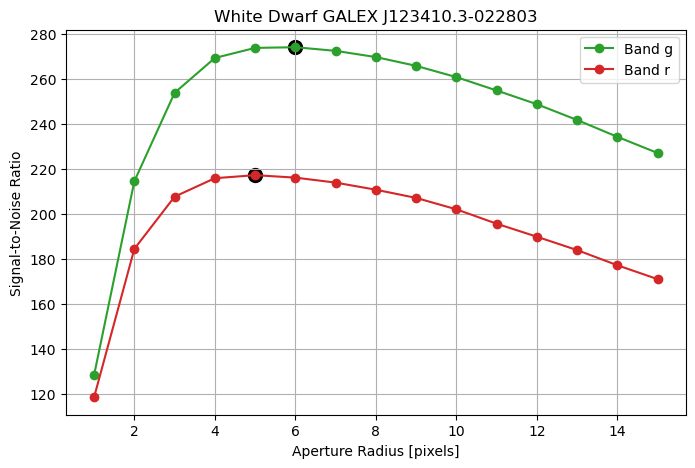

In [18]:
plt.figure(figsize=(8,5))

plt.plot(df_g['ApertureMinorRadius'], df_g['SNR'], 'o-', color='#2ca02c', label='Band g')
plt.plot(df_r['ApertureMinorRadius'], df_r['SNR'], 'o-', color='#d62728', label='Band r')

idx_g = df_g['SNR'].idxmax()
xg = df_g.loc[idx_g, 'ApertureMinorRadius']
yg = df_g.loc[idx_g, 'SNR']
plt.scatter(xg, yg, color='black', s=100)

idx_r = df_r['SNR'].idxmax()
xr = df_r.loc[idx_r, 'ApertureMinorRadius']
yr = df_r.loc[idx_r, 'SNR']
plt.scatter(xr, yr, color='black', s=100)

plt.title('White Dwarf GALEX J123410.3-022803')
plt.xlabel('Aperture Radius [pixels]')
plt.ylabel('Signal-to-Noise Ratio')
plt.legend()
plt.grid(True)

plt.show()

In [19]:
wd_g = best_g['best_mag']
wd_r = best_r['best_mag']

color = wd_g - wd_r

parallax = 1.2768  # mas
wd_d_pc = 1000 / parallax

WDMg = wd_g - 5 * np.log10(wd_d_pc) + 5
WDMr = wd_r - 5 * np.log10(wd_d_pc) + 5

M_sun_g = 5.12
M_sun_r = 4.64

L_wdg = 10**(-0.4 * (WDMg - M_sun_g))
L_wdr = 10**(-0.4 * (WDMr - M_sun_r))

print(f"""
g band:
  Optimal radius = {best_g['best_radius_px']} px
  Maximum S/N    = {best_g['best_snr']}
  Magnitude      = {wd_g}
  Mag error      = {best_g['best_mag_err']}

r band:
  Optimal radius = {best_r['best_radius_px']} px
  Maximum S/N    = {best_r['best_snr']}
  Magnitude      = {wd_r}
  Mag error      = {best_r['best_mag_err']}

Distance:
  d = {wd_d_pc} pc  (parallax = {parallax} mas)

Color:
  g - r = {color}

Absolute magnitudes:
  M_g = {WDMg}
  M_r = {WDMr}

Luminosities (relative to the Sun):
  L_g / L☉ = {L_wdg}
  L_r / L☉ = {L_wdr}
""")


g band:
  Optimal radius = 6 px
  Maximum S/N    = 274.2540021451706
  Magnitude      = 17.8778
  Mag error      = 0.1293

r band:
  Optimal radius = 5 px
  Maximum S/N    = 217.33714108705706
  Magnitude      = 18.2637
  Mag error      = 0.1545

Distance:
  d = 783.2080200501254 pc  (parallax = 1.2768 mas)

Color:
  g - r = -0.38589999999999947

Absolute magnitudes:
  M_g = 8.408414370033272
  M_r = 8.794314370033272

Luminosities (relative to the Sun):
  L_g / L☉ = 0.04837647857649959
  L_r / L☉ = 0.021790854054122823



In [10]:
star_file_g = r'C:\Users\ivanf\OneDrive\Escritorio\APT intento\star\excelFile_g.csv'
star_nmgy_g = 0.00360308     
star_gain_g = 4.035
star_dark_g = 1.8225

star_file_r = r'C:\Users\ivanf\OneDrive\Escritorio\APT intento\star\excelFile_r.csv'
star_nmgy_r = 0.00499517
star_gain_r = 4.895
star_dark_r = 0.9025  

star_df_g = process_apt_file(star_file_g, 'g', star_nmgy_g, star_gain_g, star_dark_g)
star_df_r = process_apt_file(star_file_r, 'r', star_nmgy_r, star_gain_r, star_dark_r)

star_best_g = best_aperture_info(star_df_g)
star_best_r = best_aperture_info(star_df_r)

star_g = star_best_g['best_mag']
star_r = star_best_r['best_mag']

print("Star band g:", star_best_g)
print("Star band r:", star_best_r)

Star band g: {'band': 'g', 'best_radius_px': np.int64(6), 'best_snr': np.float64(394.4410569563709), 'best_mag': np.float64(17.1059), 'best_mag_err': np.float64(0.0906)}
Star band r: {'band': 'r', 'best_radius_px': np.int64(8), 'best_snr': np.float64(439.31466425959763), 'best_mag': np.float64(16.7146), 'best_mag_err': np.float64(0.0757)}


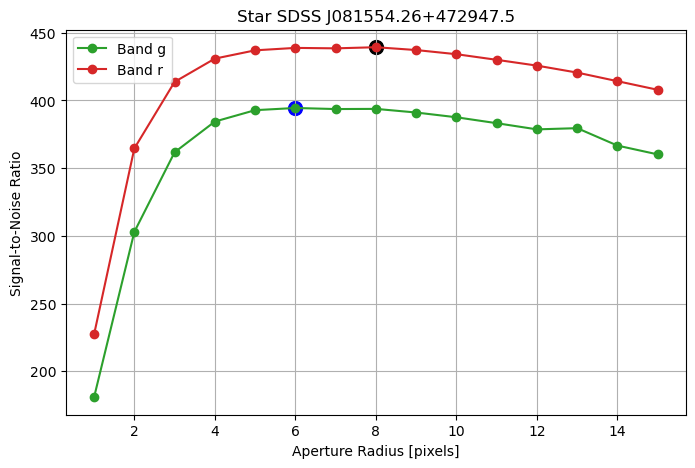

In [20]:
plt.figure(figsize=(8,5))

plt.plot(star_df_g['ApertureMinorRadius'], star_df_g['SNR'], 'o-', color='#2ca02c', label='Band g')
plt.plot(star_df_r['ApertureMinorRadius'], star_df_r['SNR'], 'o-', color='#d62728', label='Band r')

idx_g = star_df_g['SNR'].idxmax()
xg = star_df_g.loc[idx_g, 'ApertureMinorRadius']
yg = star_df_g.loc[idx_g, 'SNR']
plt.scatter(xg, yg, color='blue', s=100)

idx_r = star_df_r['SNR'].idxmax()
xr = star_df_r.loc[idx_r, 'ApertureMinorRadius']
yr = star_df_r.loc[idx_r, 'SNR']
plt.scatter(xr, yr, color='black', s=100)

plt.title('Star SDSS J081554.26+472947.5')
plt.xlabel('Aperture Radius [pixels]')
plt.ylabel('Signal-to-Noise Ratio')
plt.legend()
plt.grid(True)

plt.show()

In [21]:
star_g = star_best_g['best_mag']
star_r = star_best_r['best_mag']

star_color = star_g - star_r

star_parallax = 0.4089

star_d_pc = 1000 / star_parallax

star_Mg = star_g - 5 * np.log10(star_d_pc) + 5
star_Mr = star_r - 5 * np.log10(star_d_pc) + 5

M_sun_g = 5.12
M_sun_r = 4.64

star_L_g = 10**(-0.4 * (star_Mg - M_sun_g))
star_L_r = 10**(-0.4 * (star_Mr - M_sun_r))

print(f"""
=== STELLAR PHOTOMETRIC RESULTS ===

g band:
  Optimal radius = {star_best_g['best_radius_px']} px
  Maximum S/N    = {star_best_g['best_snr']}
  Magnitude      = {star_g}
  Mag error      = {star_best_g['best_mag_err']}

r band:
  Optimal radius = {star_best_r['best_radius_px']} px
  Maximum S/N    = {star_best_r['best_snr']}
  Magnitude      = {star_r}
  Mag error      = {star_best_r['best_mag_err']}

Distance:
  d = {star_d_pc} pc
  Parallax = {star_parallax} mas
  
Color:
  g - r = {star_color}

Absolute magnitudes:
  M_g = {star_Mg}
  M_r = {star_Mr}

Luminosities:
  L_g / L☉ = {star_L_g}
  L_r / L☉ = {star_L_r}
""")


=== STELLAR PHOTOMETRIC RESULTS ===

g band:
  Optimal radius = 6 px
  Maximum S/N    = 394.4410569563709
  Magnitude      = 17.1059
  Mag error      = 0.0906

r band:
  Optimal radius = 8 px
  Maximum S/N    = 439.31466425959763
  Magnitude      = 16.7146
  Mag error      = 0.0757

Distance:
  d = 2445.5857177794082 pc
  Parallax = 0.4089 mas

Color:
  g - r = 0.39129999999999754

Absolute magnitudes:
  M_g = 5.163985552771678
  M_r = 4.77268555277168

Luminosities:
  L_g / L☉ = 0.960297457215915
  L_r / L☉ = 0.8849643561277993



In [13]:
star_FWHM = 2.87 #pixels
wd_FWHM = 2.92 #pixels
SDSS_pixel_scale = 0.396 
star_FWHM_arc = star_FWHM * SDSS_pixel_scale
wd_FWHM_arc = wd_FWHM * SDSS_pixel_scale
print(star_FWHM_arc, wd_FWHM_arc)

1.1365200000000002 1.15632


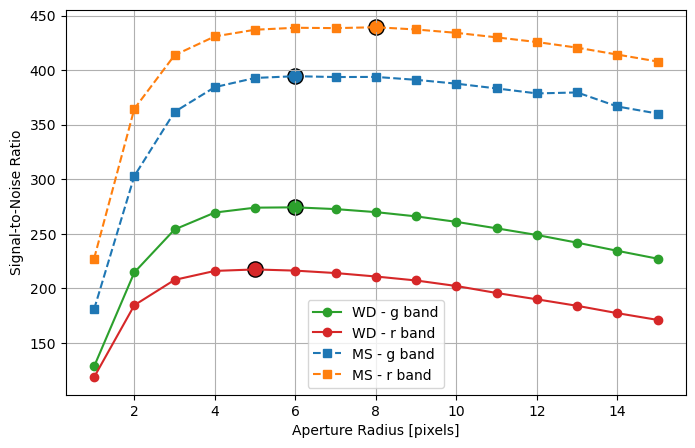

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(df_g['ApertureMinorRadius'], df_g['SNR'],
         'o-', color='#2ca02c', label='WD - g band')

plt.plot(df_r['ApertureMinorRadius'], df_r['SNR'],
         'o-', color='#d62728', label='WD - r band')

idx_g = df_g['SNR'].idxmax()
xg = df_g.loc[idx_g, 'ApertureMinorRadius']
yg = df_g.loc[idx_g, 'SNR']
plt.scatter(xg, yg, color='#2ca02c', s=120, edgecolor='black')

idx_r = df_r['SNR'].idxmax()
xr = df_r.loc[idx_r, 'ApertureMinorRadius']
yr = df_r.loc[idx_r, 'SNR']
plt.scatter(xr, yr, color='#d62728', s=120, edgecolor='black')


plt.plot(star_df_g['ApertureMinorRadius'], star_df_g['SNR'],
         's--', color='#1f77b4', label='MS - g band')

plt.plot(star_df_r['ApertureMinorRadius'], star_df_r['SNR'],
         's--', color='#ff7f0e', label='MS - r band')

idx_g = star_df_g['SNR'].idxmax()
xg = star_df_g.loc[idx_g, 'ApertureMinorRadius']
yg = star_df_g.loc[idx_g, 'SNR']
plt.scatter(xg, yg, color='#1f77b4', s=120, edgecolor='black')

idx_r = star_df_r['SNR'].idxmax()
xr = star_df_r.loc[idx_r, 'ApertureMinorRadius']
yr = star_df_r.loc[idx_r, 'SNR']
plt.scatter(xr, yr, color='#ff7f0e', s=120, edgecolor='black')


plt.xlabel('Aperture Radius [pixels]')
plt.ylabel('Signal-to-Noise Ratio')
plt.legend()
plt.grid(True)

plt.show()